<a href="https://colab.research.google.com/github/Dungmeww/ThucHanh_DeepLearning/blob/Buoi4/CNN_bai3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Đang tải dữ liệu Cats vs Dogs từ TensorFlow Datasets... ---


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

--- Bắt đầu huấn luyện mô hình mạng CNN với 10 epochs... ---
Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 935s 2s/step - accuracy: 0.6664 - loss: 0.5989 - val_accuracy: 0.7640 - val_loss: 0.4982
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 938s 2s/step - accuracy: 0.7746 - loss: 0.4688 - val_accuracy: 0.8046 - val_loss: 0.4232
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 930s 2s/step - accuracy: 0.8220 - loss: 0.3912 - val_accuracy: 0.8237 - val_loss: 0.3893
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 920s 2s/step - accuracy: 0.8599 - loss: 0.3209 - val_accuracy: 0.8306 - val_loss: 0.3800
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 922s 2s/step - accuracy: 0.8947 - loss: 0.2489 - val_accuracy: 0.8186 - val_loss: 0.5094
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 919s 2s/step - accuracy: 0.9301 - loss: 0.1702 - val_accuracy: 0.8371 - val_loss: 0.4767
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 941s 2s/step - accuracy: 0.9620 - loss: 0.1032 - val_accuracy: 0.8289 - val_loss: 0.5970
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━

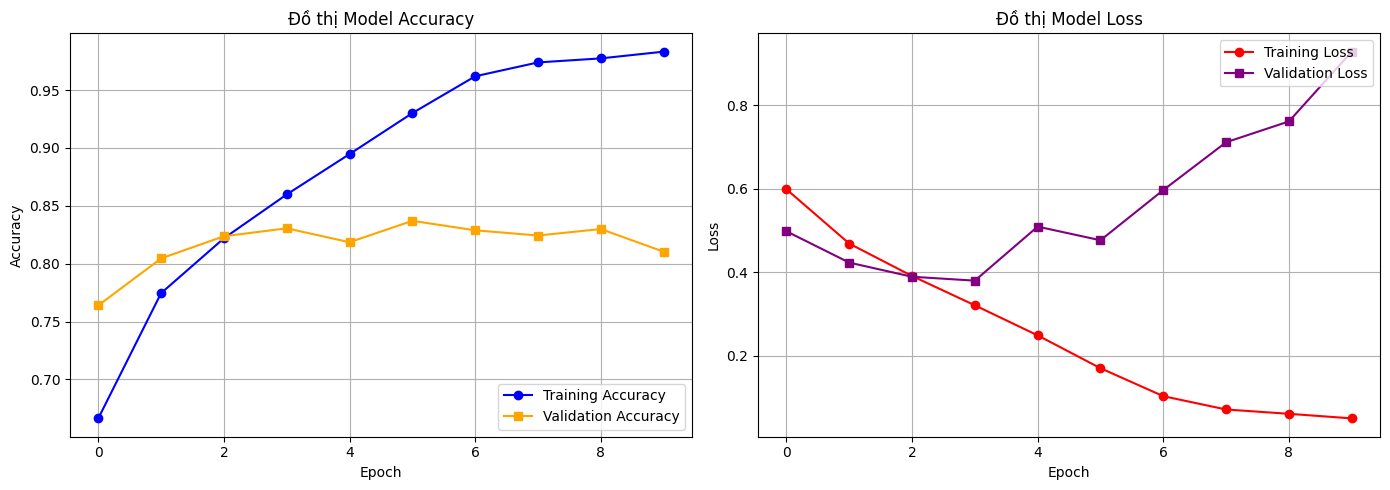

In [ ]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

print("--- Đang tải dữ liệu Cats vs Dogs từ TensorFlow Datasets... ---")

(train_ds, val_ds), info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)


IMG_SIZE = (150, 150)
BATCH_SIZE = 32

def format_example(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    return image, label

train_dataset = (train_ds
                 .map(format_example)
                 .shuffle(1000)
                 .batch(BATCH_SIZE)
                 .prefetch(tf.data.AUTOTUNE))

validation_dataset = (val_ds
                      .map(format_example)
                      .batch(BATCH_SIZE)
                      .prefetch(tf.data.AUTOTUNE))

print("Các nhãn phân loại chính xác trong tập dữ liệu:", info.features['label'].names)
print("--- Chuẩn bị dữ liệu hoàn tất! ---")

model = Sequential([
    layers.Input(shape=(150, 150, 3)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

EPOCHS = 10
print(f"--- Bắt đầu huấn luyện mô hình mạng CNN với {EPOCHS} epochs... ---")
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)
print("--- Huấn luyện thành công! ---")

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', marker='s')
plt.legend(loc='lower right')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Đồ thị Model Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='red', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='purple', marker='s')
plt.legend(loc='upper right')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Đồ thị Model Loss')
plt.grid(True)

plt.tight_layout()
plt.show()